In [ ]:
from pathlib import Path

# path setting
BASE_PATH = Path.cwd().parent.parent

RAW = BASE_PATH / 'Data' / 'raw'
TEMP = BASE_PATH / 'Data' / 'temp'
USE = BASE_PATH / 'Data' / 'use'
FIGURES = BASE_PATH / 'Results' / 'Figures'
TABLES = BASE_PATH / 'Results' / 'Tables'

for path in [RAW, TEMP, USE, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"✅ BASE_PATH: {BASE_PATH}")


In [ ]:
# Figure 1. Global data center distribution and growth trends.
# a, Geographical distribution of data centers by country. 
# b, Annual new installations by country and data center type from 2000 to 2024. 

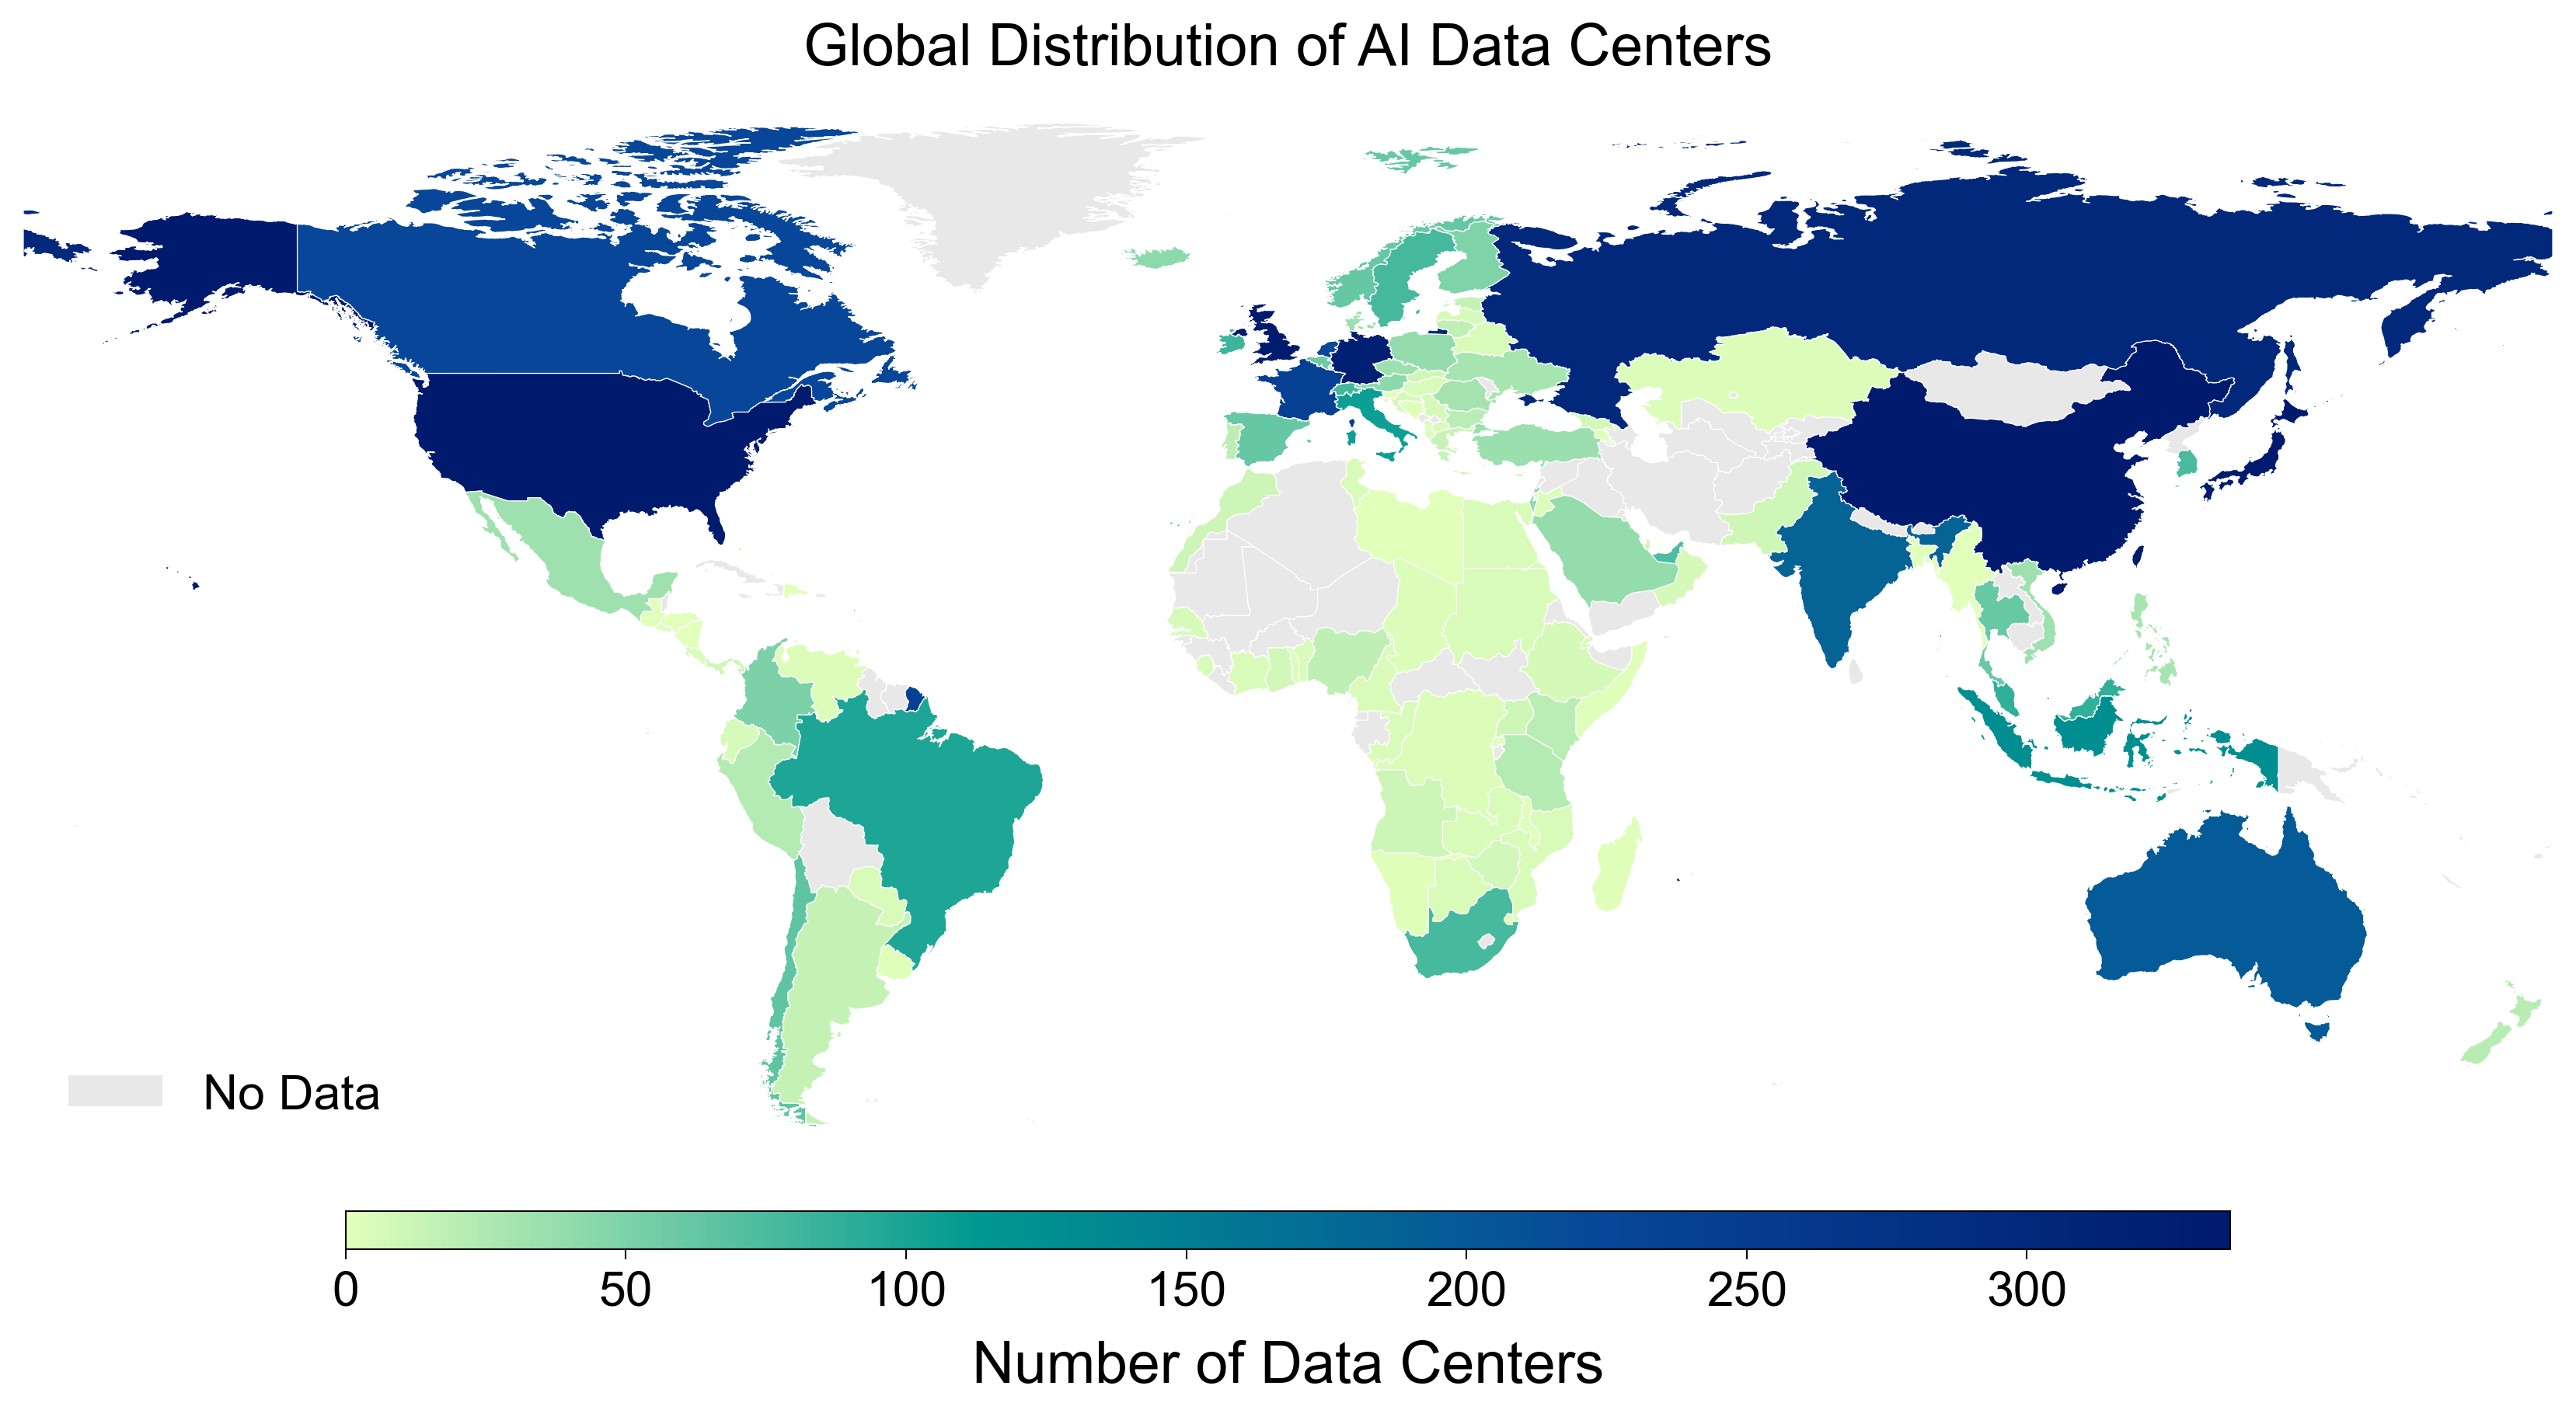


Data Filtering Summary
Total data centers after filtering: 9031
Countries with data centers: 126

Top 10 countries by number of data centers:
    Alpha-3 code  count
120          USA   2522
21           CHN   1595
59           JPN    458
42           GBR    342
31           DEU    323
95           RUS    302
41           FRA    241
18           CAN    227
81           NLD    222
6            AUS    196



In [ ]:
# Fig. 1a. Geographical distribution of data centers by country
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.linewidth': 0.5,
})

# read data
df_centers = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='Sheet1')
df_country = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='country')

# 🔥 Filter valid samples: non-missing YR_BUILT, LATITUDE, LONGITUDE, and YR_BUILT != 2025
df_centers = df_centers[
    (df_centers['YR_BUILT'].notna()) & 
    (df_centers['LATITUDE'].notna()) & 
    (df_centers['LONGITUDE'].notna()) & 
    (df_centers['YR_BUILT'] != 2025)
].copy()

# merge country info
df_merged = df_centers.merge(
    df_country[['COUNTRY', 'Alpha-3 code', 'Region']], 
    on='COUNTRY', 
    how='left'
)

# count country number
country_counts = df_merged.groupby('Alpha-3 code').size().reset_index(name='count')

# merge Hong Kong, Taiwan, and Macau into China
hkg_count = country_counts[country_counts['Alpha-3 code'] == 'HKG']['count'].sum()
twn_count = country_counts[country_counts['Alpha-3 code'] == 'TWN']['count'].sum()
mac_count = country_counts[country_counts['Alpha-3 code'] == 'MAC']['count'].sum()

if 'CHN' in country_counts['Alpha-3 code'].values:
    country_counts.loc[country_counts['Alpha-3 code'] == 'CHN', 'count'] += (hkg_count + twn_count + mac_count)
else:
    new_row = pd.DataFrame({'Alpha-3 code': ['CHN'], 'count': [hkg_count + twn_count + mac_count]})
    country_counts = pd.concat([country_counts, new_row], ignore_index=True)

# download map
url = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(url)

if 'ADM0_A3' in world.columns:
    world = world.rename(columns={'ADM0_A3': 'iso_a3', 'NAME': 'name'})

# clean
world = world[world['iso_a3'] != '-99']
world = world[world['iso_a3'].notna()]
world = world.drop_duplicates(subset=['iso_a3'], keep='first')

# merge
world = world.merge(country_counts, left_on='iso_a3', right_on='Alpha-3 code', how='left')
world['count'] = world['count'].fillna(0)

# Create display_count for display
world['display_count'] = world['count'].copy()

# Show Hong Kong, Macao, and Taiwan in China's color
chn_count = world[world['iso_a3'] == 'CHN']['count'].values
if len(chn_count) > 0:
    world.loc[world['iso_a3'].isin(['TWN', 'HKG', 'MAC']), 'count'] = 0
    world.loc[world['iso_a3'].isin(['TWN', 'HKG', 'MAC']), 'display_count'] = chn_count[0]

# no data
world['category'] = world['display_count'].apply(lambda x: 'data' if x > 0 else 'nodata')

# plot
colors = ['#E1FFBB', '#009990', '#074799', '#001A6E']
custom_cmap = LinearSegmentedColormap.from_list('custom_blue_green', colors)

fig, ax = plt.subplots(figsize=(14, 7), dpi=300)

world_nodata = world[world['category'] == 'nodata']
world_data = world[world['category'] == 'data']

world_nodata.plot(ax=ax, color='#E8E8E8', edgecolor='white', linewidth=0.3)

if len(world_data) > 0:
    world_data.plot(
        column='display_count',
        ax=ax,
        legend=False,
        cmap=custom_cmap,
        edgecolor='white',
        linewidth=0.3,
        vmin=0,
        vmax=world_data['display_count'].quantile(0.95)
    )

ax.set_xlim([-180, 180])
ax.set_ylim([-60, 85])
ax.axis('off')
ax.set_title('Global Distribution of AI Data Centers', fontsize=18, pad=15)

sm = plt.cm.ScalarMappable(
    cmap=custom_cmap,
    norm=plt.Normalize(vmin=0, vmax=world_data['display_count'].quantile(0.95))
)
sm._A = []
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.04, aspect=50)
cbar.set_label('Number of Data Centers', fontsize=18, labelpad=8)
cbar.ax.tick_params(labelsize=15, width=0.5, length=3)
cbar.outline.set_linewidth(0.5)

legend_elements = [Patch(facecolor='#E8E8E8', edgecolor='white', label='No Data')]
ax.legend(handles=legend_elements, loc='lower left', fontsize=15, frameon=False)

plt.savefig(os.path.join(FIGURES, 'fig1a_datacenter_heatmap.pdf'), bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n{'='*60}")
print(f"Data Filtering Summary")
print(f"{'='*60}")
print(f"Total data centers after filtering: {len(df_centers)}")
print(f"Countries with data centers: {df_merged['Alpha-3 code'].nunique()}")
print(f"\nTop 10 countries by number of data centers:")
print(country_counts.nlargest(10, 'count')[['Alpha-3 code', 'count']])
print(f"{'='*60}\n")


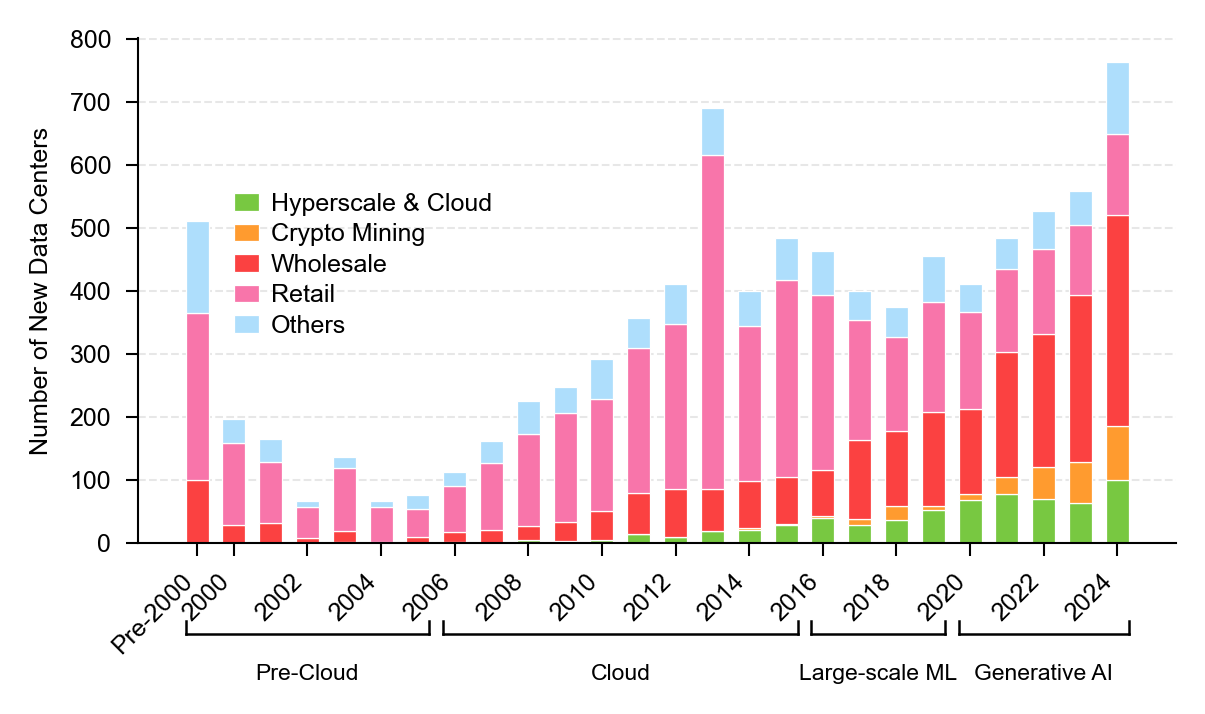

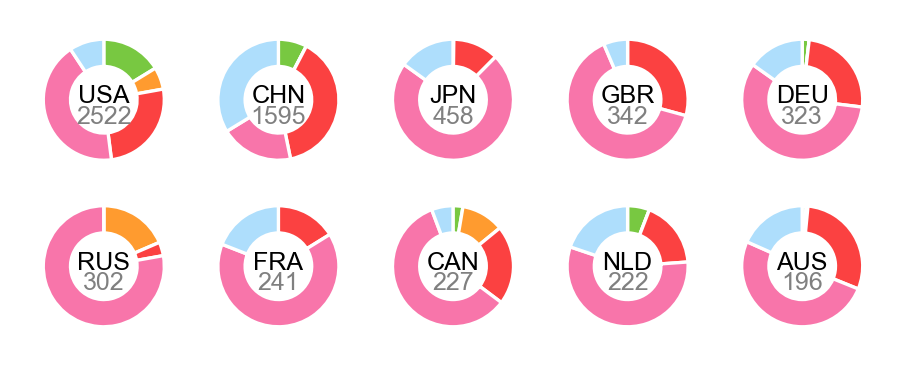


Data Filtering Summary for Fig. 1b
Total data centers after filtering: 9031
Data centers with valid year: 9031
Year range: 1912 - 2024

Top 10 countries (after merging HKG/TWN/MAC into CHN):
Alpha-3 code
USA    2522
CHN    1595
JPN     458
GBR     342
DEU     323
RUS     302
FRA     241
CAN     227
NLD     222
AUS     196
Name: count, dtype: int64

Data center types distribution:
Type_Category
Retail Data Center           4448
Wholesale Data Center        2294
Others                       1361
Hyperscale & Cloud            644
Crypto Mining Data Center     284
Name: count, dtype: int64



In [5]:
# Fig. 1b. Annual new installations by country and data center type from 2000 to 2024.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Nature style settings
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.linewidth': 0.5,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'axes.labelsize': 6,
    'legend.fontsize': 6,
})

# Read data
df_centers = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='Sheet1')
df_country = pd.read_excel(os.path.join(RAW, 'SPGlobal_Export.xlsx'), sheet_name='country')

# Filter valid samples: non-missing YR_BUILT, LATITUDE, LONGITUDE, and YR_BUILT != 2025
df_centers = df_centers[
    (df_centers['YR_BUILT'].notna()) & 
    (df_centers['LATITUDE'].notna()) & 
    (df_centers['LONGITUDE'].notna()) & 
    (df_centers['YR_BUILT'] != 2025)
].copy()

# Merge country information
df_merged = df_centers.merge(
    df_country[['COUNTRY', 'Alpha-3 code', 'Region']], 
    on='COUNTRY', 
    how='left'
)

# Filter valid years and create year groups
df_time = df_merged[df_merged['YR_BUILT'].notna()].copy()
df_time['Year_Group'] = df_time['YR_BUILT'].apply(
    lambda x: 'Pre-2000' if x < 2000 else str(int(x))
)

# Data center type colors
type_colors = {
    'Hyperscale & Cloud': '#78C841',
    'Crypto Mining Data Center': '#FF9B2F',
    'Wholesale Data Center': '#FB4141',
    'Retail Data Center': '#F875AA',
    'Others': '#AEDEFC'
}

type_order = [
    'Hyperscale & Cloud',
    'Crypto Mining Data Center',
    'Wholesale Data Center',
    'Retail Data Center',
    'Others'
]

# Categorize types
def categorize_type(type_str):
    if pd.isna(type_str):
        return 'Others'
    type_str = str(type_str).strip()
    
    if type_str in ['Hyperscale Data Center', 'Cloud Data Center']:
        return 'Hyperscale & Cloud'
    elif type_str in ['Crypto Mining Data Center', 'Wholesale Data Center', 'Retail Data Center']:
        return type_str
    else:
        return 'Others'

df_time['Type_Category'] = df_time['SECONDARY_PPTY_TYPE'].apply(categorize_type)

# ===== Part 1: Stacked bar chart by type =====
yearly_type_counts = df_time.groupby(['Year_Group', 'Type_Category']).size().reset_index(name='count')
pivot_yearly = yearly_type_counts.pivot_table(
    index='Year_Group',
    columns='Type_Category',
    values='count',
    fill_value=0
)

# Ensure all types exist
for type_name in type_order:
    if type_name not in pivot_yearly.columns:
        pivot_yearly[type_name] = 0

pivot_yearly = pivot_yearly[type_order]

# Sort years: Pre-2000 first, then 2000-2024
year_labels = ['Pre-2000'] + [str(y) for y in range(2000, 2025)]
pivot_yearly = pivot_yearly.reindex(year_labels, fill_value=0)

fig1, ax1 = plt.subplots(figsize=(4, 2.5), dpi=300)

x = np.arange(len(pivot_yearly)) * 0.8
width = 0.5
bottom = np.zeros(len(pivot_yearly))

for type_name in type_order:
    values = pivot_yearly[type_name].values
    label = type_name.replace(' Data Center', '')
    ax1.bar(
        x, values, width, bottom=bottom,
        label=label,
        color=type_colors[type_name],
        edgecolor='white', linewidth=0.3
    )
    bottom += values

ax1.set_ylabel('Number of New Data Centers')
ax1.set_xlabel('')  # remove Year

# X-axis: show Pre-2000 + every other year from 2000
tick_positions = [0] + list(range(1, len(pivot_yearly), 2))
tick_labels = [pivot_yearly.index[i] for i in tick_positions]
ax1.set_xticks([x[i] for i in tick_positions])
ax1.set_xticklabels(tick_labels, rotation=45, ha='right')

ax1.tick_params(axis='both', width=0.5, length=3)

ax1.legend(
    loc='center left',
    frameon=False,
    bbox_to_anchor=(0.07, 0.55),
    handlelength=1.0,
    handletextpad=0.5,
    labelspacing=0.3
)

ax1.yaxis.grid(True, linestyle='--', alpha=0.3, linewidth=0.5)
ax1.set_axisbelow(True)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(0.5)
ax1.spines['bottom'].set_linewidth(0.5)

# ---------- Era brackets below x-axis ----------
trans = ax1.get_xaxis_transform()

def add_era_bracket(ax, x0, x1, y, label, text_offset=-0.06, lw=0.6):
    # horizontal line
    ax.plot([x0, x1], [y, y], transform=trans, color='black', lw=lw, clip_on=False)
    # small vertical ticks
    ax.plot([x0, x0], [y, y + 0.025], transform=trans, color='black', lw=lw, clip_on=False)
    ax.plot([x1, x1], [y, y + 0.025], transform=trans, color='black', lw=lw, clip_on=False)
    # label
    ax.text((x0 + x1) / 2, y + text_offset, label,
            ha='center', va='top', transform=trans, fontsize=5.5)

# Bracket boundaries using bar edges
left_edge = lambda i: x[i] - width / 2
right_edge = lambda i: x[i] + width / 2

# index mapping:
# 0 = Pre-2000
# 1 = 2000
# ...
# 6 = 2005
# 7 = 2006
# ...
# 16 = 2015
# 17 = 2016
# 20 = 2019
# 21 = 2020
# 25 = 2024

add_era_bracket(ax1, left_edge(0), right_edge(6),  -0.18, 'Pre-Cloud')
add_era_bracket(ax1, left_edge(7), right_edge(16), -0.18, 'Cloud')
add_era_bracket(ax1, left_edge(17), right_edge(20), -0.18, 'Large-scale ML')
add_era_bracket(ax1, left_edge(21), right_edge(25), -0.18, 'Generative AI')

plt.tight_layout()
plt.subplots_adjust(bottom=0.28)

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_yearly_stacked_era_clean.tif'),
    dpi=300, bbox_inches='tight', transparent=True,
    pil_kwargs={'compression': 'tiff_lzw'}
)
plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_yearly_stacked_era_clean.pdf'),
    bbox_inches='tight', transparent=True
)

# ===== Part 2: Donut charts (Top 10 countries by count) =====
# Merge Hong Kong, Taiwan, and Macao into China
df_time_merged = df_time.copy()
df_time_merged.loc[df_time_merged['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# Automatically get top 10 countries
top10_codes = (
    df_time_merged['Alpha-3 code']
    .value_counts()
    .head(10)
    .index
    .tolist()
)

fig2, axes = plt.subplots(2, 5, figsize=(3, 1.2), dpi=300)
axes = axes.flatten()

for idx, code in enumerate(top10_codes):
    ax = axes[idx]
    country_data = df_time_merged[df_time_merged['Alpha-3 code'] == code]
    type_counts = country_data['Type_Category'].value_counts().reindex(type_order, fill_value=0)
    total = type_counts.sum()
    
    if total > 0:
        ax.pie(
            type_counts,
            colors=[type_colors[t] for t in type_order],
            startangle=90,
            counterclock=False,
            wedgeprops=dict(width=0.45, edgecolor='white', linewidth=0.8)
        )
    else:
        ax.pie(
            [1],
            colors=['#EEEEEE'],
            wedgeprops=dict(width=0.35, edgecolor='white', linewidth=0.4)
        )
    
    ax.text(0, 0.05, code, ha='center', va='center', color='black')
    ax.text(0, -0.29, f'{int(total)}', ha='center', va='center', color='gray')
    ax.axis('equal')

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_type_donuts.tif'),
    dpi=300, bbox_inches='tight', transparent=True,
    pil_kwargs={'compression': 'tiff_lzw'}
)
plt.savefig(
    os.path.join(FIGURES, 'fig1b_datacenter_type_donuts.pdf'),
    bbox_inches='tight', transparent=True
)

plt.show()

# Print filtering summary
print(f"\n{'='*60}")
print("Data Filtering Summary for Fig. 1b")
print(f"{'='*60}")
print(f"Total data centers after filtering: {len(df_centers)}")
print(f"Data centers with valid year: {len(df_time)}")
print(f"Year range: {df_time['YR_BUILT'].min():.0f} - {df_time['YR_BUILT'].max():.0f}")
print("\nTop 10 countries (after merging HKG/TWN/MAC into CHN):")
print(df_time_merged['Alpha-3 code'].value_counts().head(10))
print("\nData center types distribution:")
print(df_time['Type_Category'].value_counts())
print(f"{'='*60}\n")


In [ ]:
# Figure 2. Proximity of data centers to power generation infrastructure. 
# a, Distribution of distance between data centers (by establishment phase: <2006, 2006-2015, 2016-2019, 2020-2024) and their nearest power plants (coal, oil & gas, solar & wind) for the top 10 data center markets. 
# b, Energy source composition of generation capacity for these nearest power plants by country and phase.

In [6]:
# a, calculation section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2

# ==================== Load data ====================
oilgas_df = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="all")
oilgas_country = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="country")

coal_df = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="Units")
coal_country = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="country")

solar_df = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="all")
solar_country = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="country")

wind_df = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="Data")
wind_country = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="country")

ai_df = pd.read_excel(os.path.join(RAW, "sp_global_ai_center.xlsx"), sheet_name="Sheet1")
ai_country = pd.read_excel(os.path.join(RAW, "sp_global_ai_center.xlsx"), sheet_name="country")


# ==================== Process plant data ====================
def process_plant_data(plant_df, country_df, plant_type):
    plant_clean = plant_df[
        (plant_df['Status'].isin(['operating', 'retired'])) &
        (plant_df['Latitude'].notna()) &
        (plant_df['Longitude'].notna())
    ].copy()
    
    plant_clean['Latitude'] = pd.to_numeric(plant_clean['Latitude'], errors='coerce')
    plant_clean['Longitude'] = pd.to_numeric(plant_clean['Longitude'], errors='coerce')
    plant_clean['Start year'] = pd.to_numeric(plant_clean['Start year'], errors='coerce')
    plant_clean['Retired year'] = pd.to_numeric(plant_clean['Retired year'], errors='coerce')
    plant_clean['Capacity (MW)'] = pd.to_numeric(plant_clean['Capacity (MW)'], errors='coerce')
    
    plant_clean = plant_clean.dropna(subset=['Latitude', 'Longitude'])
    
    plant_clean = plant_clean.merge(
        country_df[['Country/Area', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
        on='Country/Area',
        how='left'
    )
    
    plant_clean['plant_type'] = plant_type
    return plant_clean

oilgas_processed = process_plant_data(oilgas_df, oilgas_country, 'Oil & Gas')
coal_processed = process_plant_data(coal_df, coal_country, 'Coal')
solar_processed = process_plant_data(solar_df, solar_country, 'Solar')
wind_processed = process_plant_data(wind_df, wind_country, 'Wind')

all_plants = pd.concat([oilgas_processed, coal_processed, solar_processed, wind_processed], ignore_index=True)

# ==================== Process AI data centers ====================
ai_clean = ai_df[
    (ai_df['LATITUDE'].notna()) &
    (ai_df['LONGITUDE'].notna())
].copy()

ai_clean['LATITUDE'] = pd.to_numeric(ai_clean['LATITUDE'], errors='coerce')
ai_clean['LONGITUDE'] = pd.to_numeric(ai_clean['LONGITUDE'], errors='coerce')
ai_clean['YR_BUILT'] = pd.to_numeric(ai_clean['YR_BUILT'], errors='coerce')

ai_clean = ai_clean.dropna(subset=['LATITUDE', 'LONGITUDE'])

ai_clean = ai_clean.merge(
    ai_country[['COUNTRY', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
    on='COUNTRY',
    how='left'
)

# Merge Hong Kong, Taiwan, and Macau into China
ai_clean.loc[ai_clean['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# ==================== Check if plant is operating ====================
def is_operating_at_time(row, ai_year):
    start_year = row['Start year']
    status = row['Status']
    retired_year = row['Retired year']
    
    if pd.isna(start_year) or start_year > ai_year:
        return False
    if status == 'operating':
        return True
    if status == 'retired':
        if retired_year >= ai_year:
            return True
    return False

# ==================== Optimized distance calculation ====================
def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Vectorized Haversine formula to calculate distances in km
    """
    R = 6371
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# ==================== Calculate distances ====================
results = []
countries = ai_clean['Alpha-3 code'].dropna().unique()

for country in countries:
    ai_country_data = ai_clean[ai_clean['Alpha-3 code'] == country]
    
    for idx, ai_row in ai_country_data.iterrows():
        ai_year = ai_row['YR_BUILT']
        
        if pd.isna(ai_year):
            continue
        
        country_plants = all_plants[all_plants['Alpha-3 code'] == country].copy()
        country_plants['is_operating'] = country_plants.apply(
            lambda x: is_operating_at_time(x, ai_year), axis=1
        )
        operating_plants = country_plants[country_plants['is_operating']]
        
        if len(operating_plants) == 0:
            continue
        
        distances_km = haversine_vectorized(
            ai_row['LATITUDE'],
            ai_row['LONGITUDE'],
            operating_plants['Latitude'].values,
            operating_plants['Longitude'].values
        )
        
        min_distance = distances_km.min()
        
        results.append({
            'country': country,
            'ai_year': ai_year,
            'nearest_distance_km': min_distance
        })

results_df = pd.DataFrame(results)

# ==================== Classify by time periods ====================
def classify_year(year):
    if pd.isna(year):
        return None
    if year < 2006:
        return "Phase I: <2006"
    elif 2006 <= year <= 2015:
        return "Phase II: 2006-2015"
    elif 2016 <= year <= 2019:
        return "Phase III: 2016-2019"
    elif 2020 <= year <= 2024:
        return "Phase IV: 2020-2024"
    return None

results_df['year_group'] = results_df['ai_year'].apply(classify_year)
results_df = results_df.dropna(subset=['year_group'])

# ==================== Save intermediate data ====================

results_df['year_group'] = pd.Categorical(
    results_df['year_group'],
    categories=["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"],
    ordered=True
)

results_df.to_csv(os.path.join(TEMP, 'intermediate_data_top10.csv'), index=False)



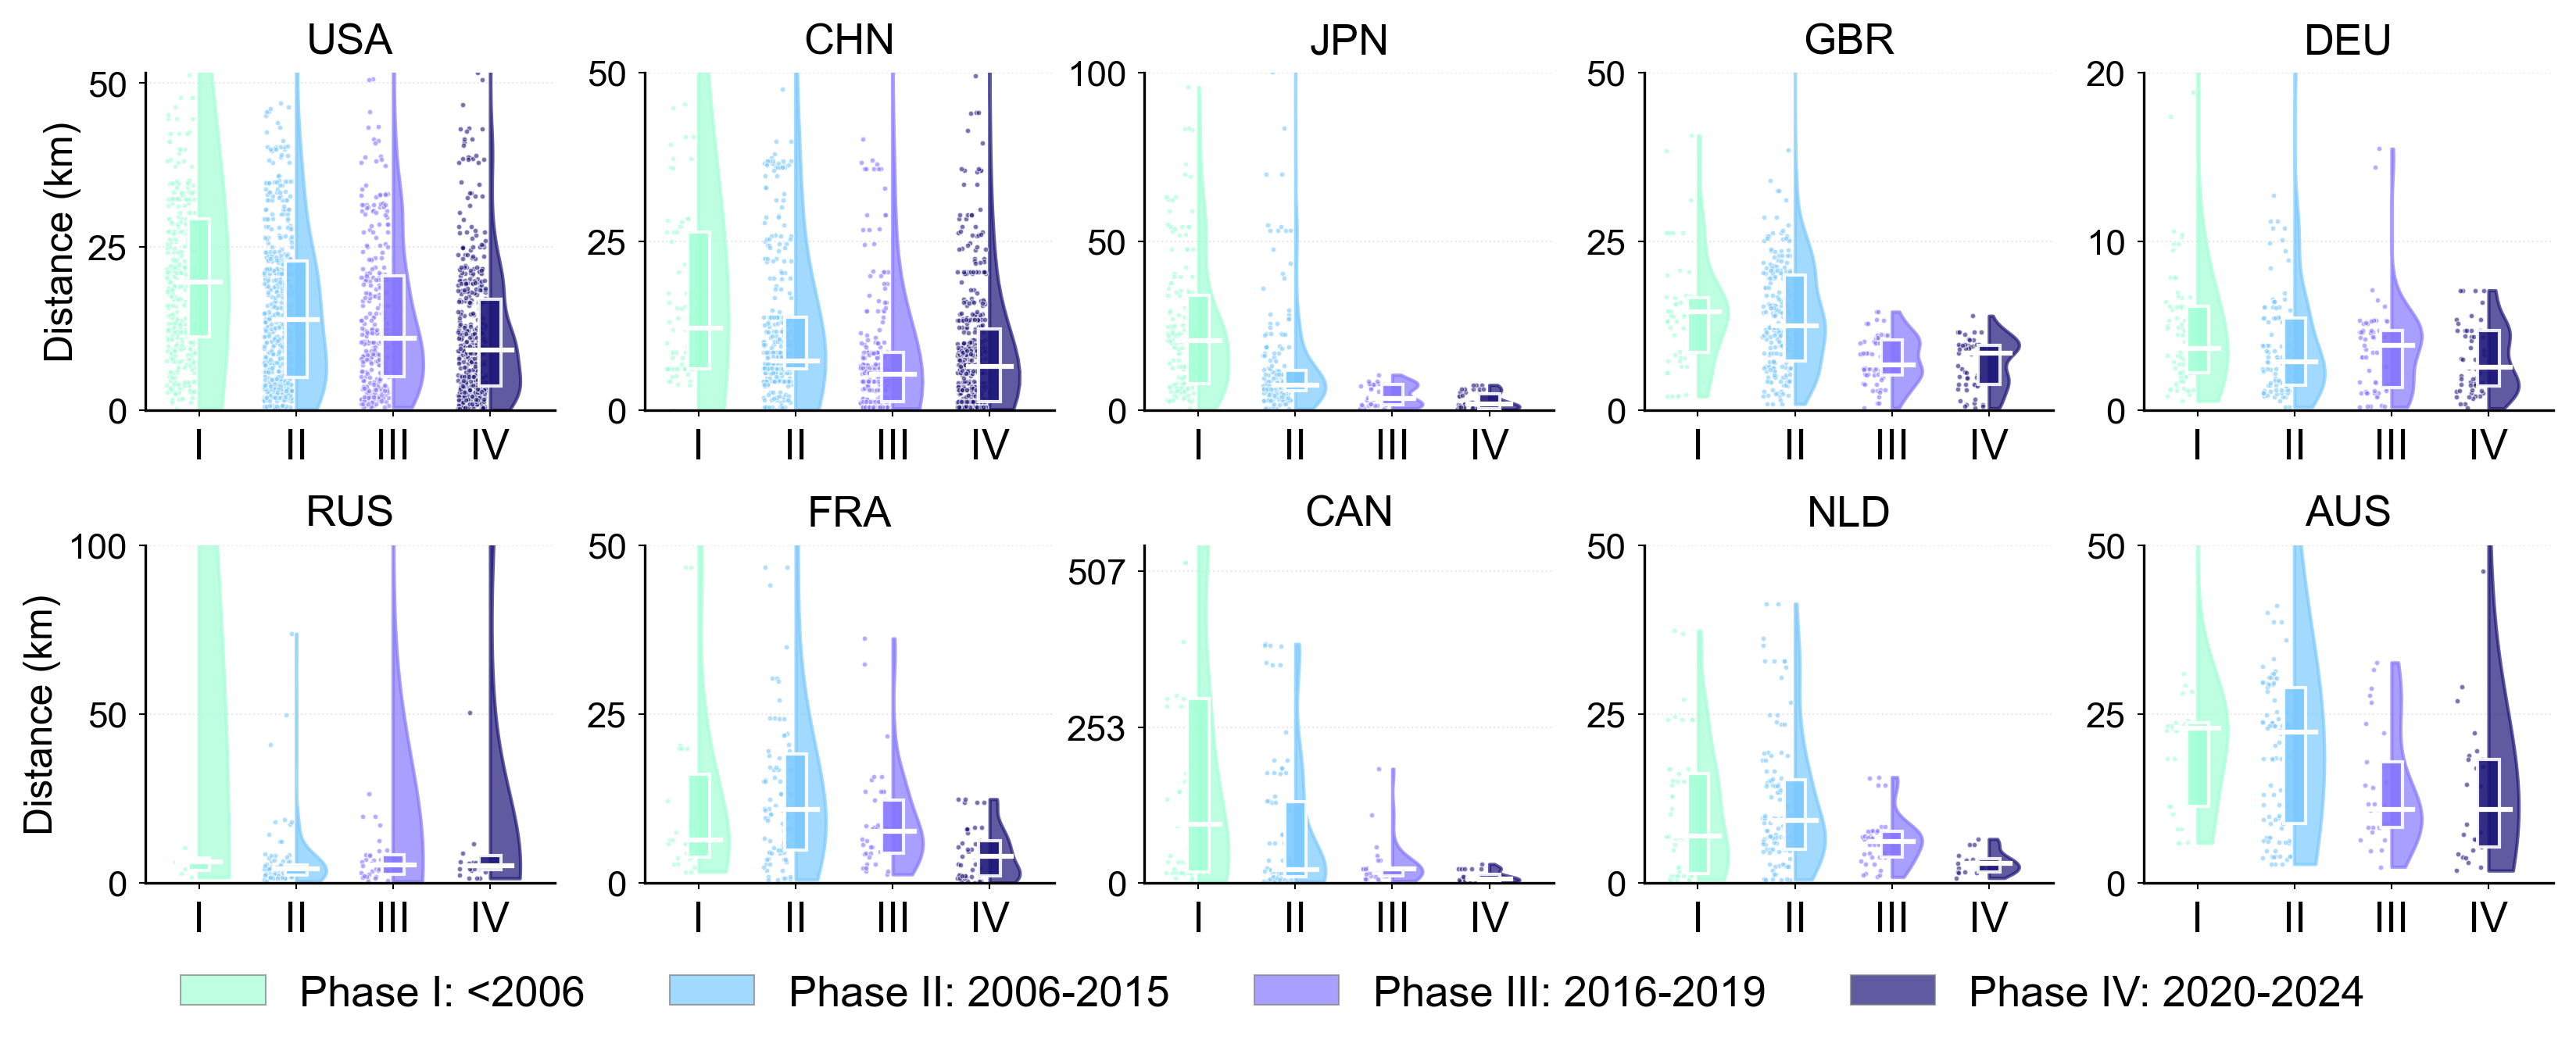

In [ ]:
# a, plot section 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Nature style settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 0.8

# ==================== Load data ====================
df_plot = pd.read_csv(os.path.join(TEMP, 'intermediate_data_top10.csv'))

df_plot['year_group'] = pd.Categorical(
    df_plot['year_group'],
    categories=["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"], 
    ordered=True
)

top10_countries = ['USA', 'CHN', 'JPN', 'GBR', 'DEU', 'RUS', 'FRA', 'CAN', 'NLD', 'AUS']

df_plot = df_plot[df_plot['country'].isin(top10_countries)].copy()
df_plot['country'] = pd.Categorical(
    df_plot['country'],
    categories=top10_countries,
    ordered=True
)


# ==================== Color scheme ====================
period_colors = {
    "Phase I: <2006": "#A3FFD6",  
    "Phase II: 2006-2015": "#7BC9FF", 
    "Phase III: 2016-2019": "#8576FF",
    "Phase IV: 2020-2024": "#1C1678"
}

# ==================== Create figure ====================
fig = plt.figure(figsize=(13, 4.8), dpi=300)

from matplotlib.gridspec import GridSpec
gs = GridSpec(2, 5, figure=fig, 
              left=0.06, right=0.85, 
              top=0.86, bottom=0.14,
              hspace=0.40, wspace=0.22)

for idx, country in enumerate(top10_countries):
    row = idx // 5
    col = idx % 5
    ax = fig.add_subplot(gs[row, col])
    
    country_data = df_plot[df_plot['country'] == country]
    
    if len(country_data) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                fontsize=11, color='gray', transform=ax.transAxes)
        ax.set_xlim(0, 2.5)
        ax.set_title(country, fontsize=12, pad=5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue
    
    positions = []
    data_list = []
    colors_list = []
    
    position_mapping = {0: 0, 1: 0.45, 2: 0.9, 3: 1.35}
    
    
    for i, period in enumerate(["Phase I: <2006", "Phase II: 2006-2015", "Phase III: 2016-2019", "Phase IV: 2020-2024"]): 
        period_data = country_data[country_data['year_group'] == period]['nearest_distance_km']
        if len(period_data) >= 1:
            positions.append(position_mapping[i])
            data_list.append(period_data.values)
            colors_list.append(period_colors[period])

    
    if len(data_list) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                fontsize=11, color='gray', transform=ax.transAxes)
        ax.set_xlim(0, 2.5)
        ax.set_title(country, fontsize=12, pad=5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        continue
    
    # Violin plot
    parts = ax.violinplot(data_list, positions=positions, widths=0.28,
                          showmeans=False, showmedians=False, showextrema=False)
    
    for pc, color in zip(parts['bodies'], colors_list):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
        pc.set_edgecolor(color)
        pc.set_linewidth(1.0)
        
        vertices = pc.get_paths()[0].vertices
        center_x = positions[colors_list.index(color)]
        vertices[:, 0] = np.clip(vertices[:, 0], center_x, center_x + 0.28)
    
    # Box plot
    for i, (pos, data) in enumerate(zip(positions, data_list)):
        q1, median, q3 = np.percentile(data, [25, 50, 75])
        
        ax.plot([pos-0.10, pos+0.10], [median, median], 
                color='white', linewidth=1.5, zorder=4)
        
        ax.add_patch(Rectangle((pos - 0.05, q1), 0.10, q3-q1,
                               facecolor=colors_list[i], edgecolor='white',
                               alpha=0.9, linewidth=1.0, zorder=3))
    
    # Scatter points
    for i, (pos, data) in enumerate(zip(positions, data_list)):
        jitter = np.random.uniform(-0.15, -0.02, len(data))
        ax.scatter(pos + jitter, data, alpha=0.6, s=2.5,
                  color=colors_list[i], edgecolors='white',
                  linewidths=0.3, zorder=2)
    
    ax.set_xlim(-0.25, 1.65)
    
    all_data = np.concatenate(data_list)
    y_max = np.percentile(all_data, 95)
    y_max = max(y_max, 10)
    ax.set_ylim(0, y_max * 1.08)
    
    ax.set_xticks([0, 0.45, 0.9, 1.35])
    ax.set_xticklabels(['I', 'II', 'III', 'IV'], fontsize=13, ha='center')
    
    if y_max <= 20:
        y_ticks = [0, 10, 20]
    elif y_max <= 50:
        y_ticks = [0, 25, 50]
    elif y_max <= 100:
        y_ticks = [0, 50, 100]
    else:
        y_ticks = [0, int(y_max/2), int(y_max)]
    
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([f'{int(y)}' for y in y_ticks], fontsize=11)
    
    ax.set_title(country, fontsize=13, pad=6)
    ax.grid(axis='y', linestyle=':', alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    if col == 0:
        ax.set_ylabel('Distance (km)', fontsize=12, labelpad=2)

# ==================== Legend ====================
legend_elements = [
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase I: <2006"], alpha=0.7,  
              edgecolor='gray', linewidth=0.5, label='Phase I: <2006'),  
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase II: 2006-2015"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase II: 2006-2015'), 
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase III: 2016-2019"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase III: 2016-2019'),
    Rectangle((0, 0), 1, 1, fc=period_colors["Phase IV: 2020-2024"], alpha=0.7, 
              edgecolor='gray', linewidth=0.5, label='Phase IV: 2020-2024')
]


fig.legend(handles=legend_elements, 
          loc='lower center',
          bbox_to_anchor=(0.43, -0.01),
          ncol=4,
          frameon=False, 
          fontsize=13)


plt.savefig(os.path.join(FIGURES, 'fig2a.pdf'), dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# b, calculation section

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ==================== Settings ====================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5

# ==================== Load data ====================
oilgas_df = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="all")
oilgas_country = pd.read_excel(os.path.join(RAW, "Global-Oil-and-Gas-Plant-Tracker-GOGPT-January-2025.xlsx"), sheet_name="country")

coal_df = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="Units")
coal_country = pd.read_excel(os.path.join(RAW, "Global-Coal-Plant-Tracker-January-2025.xlsx"), sheet_name="country")

solar_df = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="all")
solar_country = pd.read_excel(os.path.join(RAW, "Global-Solar-Power-Tracker-February-2025.xlsx"), sheet_name="country")

wind_df = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="Data")
wind_country = pd.read_excel(os.path.join(RAW, "Global-Wind-Power-Tracker-February-2025.xlsx"), sheet_name="country")

ai_df = pd.read_excel(os.path.join(RAW, "SPGlobal_Export.xlsx"), sheet_name="Sheet1")
ai_country = pd.read_excel(os.path.join(RAW, "SPGlobal_Export.xlsx"), sheet_name="country")


# ==================== Process plant data ====================
def process_plant_data(plant_df, country_df, plant_type):
    plant_clean = plant_df[
        (plant_df['Status'].isin(['operating', 'retired'])) &
        (plant_df['Latitude'].notna()) &
        (plant_df['Longitude'].notna())
    ].copy()
    
    plant_clean['Latitude'] = pd.to_numeric(plant_clean['Latitude'], errors='coerce')
    plant_clean['Longitude'] = pd.to_numeric(plant_clean['Longitude'], errors='coerce')
    plant_clean['Start year'] = pd.to_numeric(plant_clean['Start year'], errors='coerce')
    plant_clean['Retired year'] = pd.to_numeric(plant_clean['Retired year'], errors='coerce')
    plant_clean['Capacity (MW)'] = pd.to_numeric(plant_clean['Capacity (MW)'], errors='coerce')
    
    plant_clean = plant_clean.dropna(subset=['Latitude', 'Longitude'])
    
    plant_clean = plant_clean.merge(
        country_df[['Country/Area', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
        on='Country/Area',
        how='left'
    )
    
    plant_clean['plant_type'] = plant_type
    return plant_clean

oilgas_processed = process_plant_data(oilgas_df, oilgas_country, 'Oil & Gas')
coal_processed = process_plant_data(coal_df, coal_country, 'Coal')
solar_processed = process_plant_data(solar_df, solar_country, 'Solar')
wind_processed = process_plant_data(wind_df, wind_country, 'Wind')

all_plants = pd.concat([oilgas_processed, coal_processed, solar_processed, wind_processed], ignore_index=True)

# ==================== Process AI data centers ====================
ai_clean = ai_df[
    (ai_df['LATITUDE'].notna()) &
    (ai_df['LONGITUDE'].notna())
].copy()

ai_clean['LATITUDE'] = pd.to_numeric(ai_clean['LATITUDE'], errors='coerce')
ai_clean['LONGITUDE'] = pd.to_numeric(ai_clean['LONGITUDE'], errors='coerce')
ai_clean['YR_BUILT'] = pd.to_numeric(ai_clean['YR_BUILT'], errors='coerce')

ai_clean = ai_clean.dropna(subset=['LATITUDE', 'LONGITUDE'])

ai_clean = ai_clean.merge(
    ai_country[['COUNTRY', 'Alpha-2 code', 'Alpha-3 code', 'Numeric', 'Region']],
    on='COUNTRY',
    how='left'
)

# Merge Hong Kong, Taiwan, and Macau into China
ai_clean.loc[ai_clean['Alpha-3 code'].isin(['HKG', 'TWN', 'MAC']), 'Alpha-3 code'] = 'CHN'

# ==================== Check if plant is operating ====================
def is_operating_at_time(row, ai_year):
    start_year = row['Start year']
    status = row['Status']
    retired_year = row['Retired year']
    
    if pd.isna(start_year) or start_year > ai_year:
        return False
    if status == 'operating':
        return True
    if status == 'retired':
        if retired_year >= ai_year:
            return True
    return False

# ==================== Optimized distance calculation ====================
def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def find_nearest_plant(ai_coords, operating_plants):
    """
    Find the nearest power plant to the AI data center.
    Returns: plant_type, capacity, distance
    """
    if len(operating_plants) == 0:
        return None, 0, np.nan
    
    distances = haversine_vectorized(
        ai_coords[0], 
        ai_coords[1],
        operating_plants['Latitude'].values,
        operating_plants['Longitude'].values
    )
    
    # Find the index of the nearest plant
    nearest_idx = np.argmin(distances)
    nearest_plant = operating_plants.iloc[nearest_idx]
    
    return (nearest_plant['plant_type'], 
            nearest_plant['Capacity (MW)'], 
            distances[nearest_idx])

# ==================== Calculate nearest plant for each DC ====================
results = []
countries = ai_clean['Alpha-3 code'].dropna().unique()

for country in countries:
    ai_country_data = ai_clean[ai_clean['Alpha-3 code'] == country]
    country_plants = all_plants[all_plants['Alpha-3 code'] == country].copy()
    
    if len(country_plants) == 0:
        continue
    
    for idx, ai_row in ai_country_data.iterrows():
        ai_year = ai_row['YR_BUILT']
        
        if pd.isna(ai_year):
            continue
        
        country_plants['is_operating'] = country_plants.apply(
            lambda x: is_operating_at_time(x, ai_year), axis=1
        )
        operating_plants = country_plants[country_plants['is_operating']]
        
        if len(operating_plants) == 0:
            continue
        
        ai_coords = (ai_row['LATITUDE'], ai_row['LONGITUDE'])
        plant_type, capacity, distance = find_nearest_plant(ai_coords, operating_plants)
        
        # Initialize all capacities to 0
        coal_cap = 0
        oilgas_cap = 0
        solar_wind_cap = 0
        
        # Assign capacity based on plant type
        if plant_type == 'Coal':
            coal_cap = capacity
        elif plant_type == 'Oil & Gas':
            oilgas_cap = capacity
        elif plant_type in ['Solar', 'Wind']:
            solar_wind_cap = capacity
        
        results.append({
            'country': country,
            'ai_year': ai_year,
            'coal_capacity_mw': coal_cap,
            'oilgas_capacity_mw': oilgas_cap,
            'solar_wind_capacity_mw': solar_wind_cap
        })

results_df = pd.DataFrame(results)

# ==================== Classify by time periods ====================
def classify_year(year):
    if pd.isna(year):
        return None
    if year < 2006:
        return "<2006"
    elif 2006 <= year <= 2015:
        return "2006-2015"
    elif 2016 <= year <= 2019:
        return "2016-2019"
    elif 2020 <= year <= 2024:
        return "2020-2024"
    return None

results_df['year_group'] = results_df['ai_year'].apply(classify_year)
results_df = results_df.dropna(subset=['year_group'])

# ==================== Calculate total capacity by country and period ====================
country_stats = results_df.groupby(['country', 'year_group']).agg({
    'coal_capacity_mw': 'sum',
    'oilgas_capacity_mw': 'sum',
    'solar_wind_capacity_mw': 'sum',
    'ai_year': 'count'
}).reset_index()

country_stats.columns = ['country', 'year_group', 'coal_cap_avg', 'oilgas_cap_avg', 
                         'solar_wind_cap_avg', 'total']


plot_data = country_stats.copy()

# Calculate percentages
plot_data['total_capacity'] = (plot_data['coal_cap_avg'] + 
                                plot_data['oilgas_cap_avg'] + 
                                plot_data['solar_wind_cap_avg'])


plot_data['coal_pct'] = (plot_data['coal_cap_avg'] / plot_data['total_capacity']) * 100
plot_data['oilgas_pct'] = (plot_data['oilgas_cap_avg'] / plot_data['total_capacity']) * 100
plot_data['solar_wind_pct'] = (plot_data['solar_wind_cap_avg'] / plot_data['total_capacity']) * 100

# Save intermediate data
plot_data.to_csv(os.path.join(TEMP, 'capacity_composition_data.csv'), index=False)


In [ ]:
# b, plot section 
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

# Read data
plot_data = pd.read_csv(os.path.join(TEMP, 'capacity_composition_data.csv'))

# ==================== Top 10 ====================
top10_countries = ['USA', 'CHN', 'JPN', 'GBR', 'DEU', 'RUS', 'FRA', 'CAN', 'NLD', 'AUS']


# Set categorical order
plot_data['country'] = pd.Categorical(plot_data['country'], categories=top10_countries, ordered=True)
plot_data['year_group'] = pd.Categorical(
    plot_data['year_group'],
    categories=["<2006", "2006-2015", "2016-2019", "2020-2024"],
    ordered=True
)
plot_data = plot_data.sort_values(['country', 'year_group'])

# Nature color scheme
coal_color = '#000000'
oilgas_color = '#E43636'
solar_wind_color = '#78C841'

# Hatch patterns for 4 periods
hatch_patterns = ['', '......', '//////', 'xxxxxx']
period_labels = ["<2006", "2006-2015", "2016-2019", "2020-2024"]

# Create figure
fig, ax = plt.subplots(figsize=(6, 2.2), dpi=300)

# Prepare x-axis positions
x_positions = []
x_labels = []
bar_width = 0.12
gap_between_bars = 0.03
gap_between_countries = 0.2

current_x = 0
for country in top10_countries:
    country_data = plot_data[plot_data['country'] == country]
    
    for j, period in enumerate(period_labels):
        x_pos = current_x + j * (bar_width + gap_between_bars)
        x_positions.append(x_pos)
        
        period_data = country_data[country_data['year_group'] == period]
        
        if len(period_data) > 0:
            coal_pct = period_data['coal_pct'].values[0]
            oilgas_pct = period_data['oilgas_pct'].values[0]
            solar_wind_pct = period_data['solar_wind_pct'].values[0]
            
            hatch = hatch_patterns[j]
            
            # Stacked bars with hatches
            ax.bar(x_pos, coal_pct, bar_width, 
                   color=coal_color, edgecolor='white', linewidth=0.2, hatch=hatch)
            
            ax.bar(x_pos, oilgas_pct, bar_width, bottom=coal_pct,
                   color=oilgas_color, edgecolor='white', linewidth=0.2, hatch=hatch)
            
            ax.bar(x_pos, solar_wind_pct, bar_width, bottom=coal_pct + oilgas_pct,
                   color=solar_wind_color, edgecolor='white', linewidth=0.2, hatch=hatch)
    
    # Country label position
    country_center = current_x + (3 * (bar_width + gap_between_bars)) / 2
    x_labels.append(country_center)
    
    # Update next country starting position
    current_x += 4 * (bar_width + gap_between_bars) + gap_between_countries

# Set axes
ax.set_xlim(-0.3, current_x - gap_between_countries + 0.3)
ax.set_ylim(0, 100)

# X-axis
ax.set_xticks(x_labels)
ax.set_xticklabels(top10_countries, fontsize=6, family='Arial')

# Y-axis
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=6, family='Arial')
ax.set_ylabel('Percentage of Total Capacity (%)', fontsize=6, family='Arial')

# Grid
ax.grid(axis='y', linestyle='-', alpha=0.2, linewidth=0.5, zorder=0, color='gray')
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)


# ============ Legends (right side, vertical) ============
legend_x = 0.99
legend_y_start = 0.75
legend_spacing = 0.08

# Energy type legend
color_legend_elements = [
    {'color': coal_color, 'label': 'Coal'},
    {'color': oilgas_color, 'label': 'Oil & Gas'},
    {'color': solar_wind_color, 'label': 'Solar & Wind'}
]

for i, elem in enumerate(color_legend_elements):
    y_pos = legend_y_start - i * legend_spacing
    
    rect = Rectangle((legend_x, y_pos), 0.02, 0.03,
                     transform=ax.transAxes,
                     facecolor=elem['color'],
                     edgecolor='black',
                     linewidth=0.5,
                     clip_on=False)
    ax.add_patch(rect)
    
    ax.text(legend_x + 0.03, y_pos + 0.015,
            elem['label'],
            transform=ax.transAxes,
            fontsize=6,
            family='Arial',
            va='center',
            ha='left')

# Period legend
hatch_legend_elements = [
    {'hatch': '', 'label': '<2006'},
    {'hatch': '......', 'label': '2006-2015'},
    {'hatch': '//////', 'label': '2016-2019'},
    {'hatch': 'xxxxxx', 'label': '2020-2024'}
]

legend_y_start2 = legend_y_start - 4 * legend_spacing

for i, elem in enumerate(hatch_legend_elements):
    y_pos = legend_y_start2 - i * legend_spacing
    
    rect = Rectangle((legend_x, y_pos), 0.02, 0.03,
                     transform=ax.transAxes,
                     facecolor='white',
                     edgecolor='black',
                     linewidth=0.2,
                     hatch=elem['hatch'],
                     clip_on=False)
    ax.add_patch(rect)
    
    ax.text(legend_x + 0.03, y_pos + 0.015,
            elem['label'],
            transform=ax.transAxes,
            fontsize=6,
            family='Arial',
            va='center',
            ha='left')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'fig2b.pdf'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {os.path.join(FIGURES, 'fig2b.pdf')}")
print(f"Countries displayed: {', '.join(top10_countries)}")
